In [17]:
import pandas as pd
import numpy as np
import re
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from functools import reduce

In [18]:
cases = ['noemissionscap', '60pct', '90pct']
flow_dfs = {}

for case in cases:
    flows = pd.read_csv('results/' + case + '/results/flows.csv')
    flow_dfs[case] = flows

In [19]:
def get_flow_sums_by_tech(
    flow_df,
    include_keywords=None,     # list of substrings to keep column names
    drop_techs=None            # list of tech names to drop
):
    """
    Build a Region × Technology CO₂ emissions table (Region = rows).
    """

    # --- 1. Select columns based on include_keywords ---
    if include_keywords is None:
        include_keywords = ["co2_edge", "co2_emissions_edge"]

    co2_cols = [
        c for c in flow_df.columns
        if any(kw in c for kw in include_keywords)
    ]


    # --- Region sort ---
    def region_sort_key(name):
        match = re.search(r"Region(\d+)", name)
        return int(match.group(1)) if match else 999

    co2_cols = sorted(co2_cols, key=region_sort_key)

    # --- 2. Sum flows across time for these columns ---
    co2_flow = flow_df[co2_cols]
    co2_sums = co2_flow.sum()

    # --- 3. Extract Region and Technology names ---
    region_pattern = re.compile(r"Region\d+([A-Za-z]+)")
    tech_pattern = re.compile(r"Region\d+[A-Za-z]+_(.*)")

    region_names = [region_pattern.search(i).group(1) for i in co2_sums.index]
    tech_names   = [tech_pattern.search(i).group(1) for i in co2_sums.index]

    df = pd.DataFrame({
        "Region": region_names,
        "Technology": tech_names,
        "Value": co2_sums.values
    })

    co2_by_region_tech = df.pivot_table(
        index="Region",
        columns="Technology",
        values="Value",
        aggfunc="sum"
    )

    # Sort technologies (column names) alphabetically
    co2_by_region_tech = co2_by_region_tech[
        sorted(co2_by_region_tech.columns, key=lambda x: x.lower())
    ]

    # --- 5. Drop unwanted technologies (columns now!) ---
    if drop_techs is not None:
        existing = [t for t in drop_techs if t in co2_by_region_tech.columns]
        co2_by_region_tech = co2_by_region_tech.drop(columns=existing)

    return co2_by_region_tech


In [20]:
co2_by_region_tech_dict = {}
co2_all_china_by_tech = pd.DataFrame()

for case in cases:
    co2_by_region_tech = get_flow_sums_by_tech(
    flow_dfs[case],
    include_keywords=["co2_edge", "co2_emissions_edge"],
    drop_techs=["nuclear_co2_edge", "oxyfuelcement_co2_emissions_edge"]
)   
    co2_by_region_tech_dict[case] = co2_by_region_tech
    co2_all_china_by_tech[case] = co2_by_region_tech.sum()

In [21]:
co2_all_china_by_tech

,noemissionscap,60pct,90pct
Technology,,,
1000MW_sub_co2_edge,4.704838e+06,8.580111e+03,3.716630e+03
1000MW_super_CCS_co2_edge,4.447686e+03,4.036200e+03,2.155462e+03
1000MW_super_co2_edge,3.122171e+07,2.131144e+04,8.943635e+03
1000MW_ultra_CCS_co2_edge,4.870353e+03,4.446747e+03,2.347337e+03
1000MW_ultra_co2_edge,1.149899e+08,2.332386e+07,2.015185e+06
300MW_sub_co2_edge,3.877100e+07,1.357859e+04,5.082487e+03
300MW_super_co2_edge,6.996368e+05,8.649022e+03,3.549769e+03
600MW_sub_co2_edge,6.829527e+07,1.181135e+04,4.187079e+03
600MW_super_CCS_co2_edge,3.471614e+03,3.677882e+03,2.135745e+03


# Plot CO2 Emissions by Region and Tech

In [22]:
scenario_map = {
    "noemissionscap": "No Emissions Policy",
    "60pct": "60% Emissions Reduction",
    "90pct": "90% Emissions Reduction"
}

In [ ]:
# Make Name Map
tech_name_map = {
    "oxyfuelcement_retrofit_co2_emissions_edge": "Oxyfuel Cement Retrofit",
    "tradcement_co2_emissions_edge": "Traditional Cement",

    "bfbof_co2_edge": "BF-BOF",
    "bfbofccs_retrofit_co2_edge": "BF-BOF-CCS Retrofit",
    "bfbofccs_co2_edge": "BF-BOF-CCS",
    "scrap_eaf_56_co2_edge": "Scrap EAF 56%",
    "scrap_eaf_100_retrofit_co2_edge": "Scrap EAF 100% Retrofit",
    "scrap_eaf_100_co2_edge": "Scrap EAF 100%",

    "aluminum_smelting_co2_edge": "Aluminum Smelting",

    "naturalgas_power_co2_edge": "Natural Gas Power",
    "naturalgas_power_CCS_co2_edge": "Natural Gas CCS Power",

    "300MW_sub_co2_edge": "Coal 300 MW (Subcritical)",
    "300MW_super_co2_edge": "Coal 300 MW (Supercritical)",

    "600MW_sub_co2_edge": "Coal 600 MW (Subcritical)",
    "600MW_super_co2_edge": "Coal 600 MW (Supercritical)",
    "600MW_ultra_co2_edge": "Coal 600 MW (Ultra-supercritical)",

    "1000MW_sub_co2_edge": "Coal 1000 MW (Subcritical)",
    "1000MW_super_co2_edge": "Coal 1000 MW (Supercritical)",
    "1000MW_ultra_co2_edge": "Coal 1000 MW (Ultra-supercritical)",

    "600MW_ultra_CCS_co2_edge": "Coal-CCS 600 MW (Ultra-supercritical)",
    "600MW_super_CCS_co2_edge": "Coal-CCS 600 MW (Supercritical)",

    "1000MW_ultra_CCS_co2_edge": "Coal-CCS 1000 MW (Ultra-supercritical)",
    "1000MW_super_CCS_co2_edge": "Coal-CCS 1000 MW (Supercritical)",
}

In [24]:
custom_color_map = {
    # "Retired Cement": "#a9a09f",
    # "Oxyfuel Cement Retrofit": "#ff9d9a",
    # "Traditional Cement": "#e15759",

    "BF-BOF": "#1f77b4",
    "BF-BOF-CCS Retrofit": "#aec7e8",
    "BF-BOF-CCS": "#0ee3ff",
    "Scrap EAF 56%": "#38a938",
    "Scrap EAF 100% Retrofit": "#98df8a",
    "Scrap EAF 100%": "#6acaa2",

    "Natural Gas Power": "#eb7a23",

    "Coal 300 MW (Subcritical)": "#4a5568",
    "Coal 300 MW (Supercritical)": "#8c9db1",

    "Coal 600 MW (Subcritical)": "#4e3b31",
    "Coal 600 MW (Supercritical)": "#796a5d",
    "Coal 600 MW (Ultra-supercritical)": "#a48b7f",

    "Coal 1000 MW (Subcritical)": "#1c1c1c",
    "Coal 1000 MW (Supercritical)": "#7d7d7d",
    "Coal 1000 MW (Ultra-supercritical)": "#bdbdbd",

    "Hydropower": "#3e6496",
    "Solar PV (Centralized)":"#fbb04e",
    "Solar PV (Distributed)": "#f1ce63",
    "Wind (Offshore)": "#638fbb",
    "Wind (Onshore)": "#90bfe2",
    "Battery Storage": "#9f6490",
    "Nuclear": "#3c8782",
    "Pumped Hydro Storage": "#75afa7"
}


In [28]:
import plotly.express as px
import pandas as pd

def plot_stacked_bar(
    df,
    scenario_map=None,      # maps scenario/column names to pretty names
    name_map=None,          # maps technology names (index) to pretty names
    color_map=None,         # maps pretty tech names --> colors
    title_name="none",
    xaxis_name="none",
    yaxis_name="none",
    width=1200,
    height=600,
):
    """
    Create a stacked bar plot where:
      - each COLUMN of df becomes a bar (scenario)
      - each ROW/index becomes a stacked segment (technology)

    New features:
      • scenario_map: dict mapping df column → label
      • title_name, xaxis_name, yaxis_name: optional labels (default = "none")
    """

    # --- Apply scenario_map to rename incoming bar labels ---
    if scenario_map:
        df = df.rename(index=scenario_map)

    # Transpose so that each scenario becomes one bar
    df = df.T

    # Ensure the index has a name
    if not df.index.name:
        df = df.copy()
        df.index.name = "Category"

    row_label = df.index.name

    # Convert to long format
    df_long = df.reset_index().melt(
        id_vars=row_label,
        var_name="Scenario",
        value_name="Value"
    )

    # --- Apply name_map to legend entries (index entries) ---
    display_col = row_label + "_Display"

    if name_map:
        df_long[display_col] = df_long[row_label].map(lambda x: name_map.get(x, x))
    else:
        df_long[display_col] = df_long[row_label]

    # --- If color_map is provided, remap using the display names ---
    if color_map and name_map:
        color_map = {name_map.get(k, k): v for k, v in color_map.items()}

    fig = px.bar(
        df_long,
        x="Scenario",
        y="Value",
        color=display_col,
        title=None if title_name == "none" else title_name,
        labels={
            "Scenario": xaxis_name if xaxis_name != "none" else "Scenario",
            "Value": yaxis_name if yaxis_name != "none" else "Value",
            display_col: row_label
        },
        color_discrete_map=color_map,
    )

    fig.update_layout(
        barmode="stack",
        template="plotly_white",
        width=width,
        height=height,
        margin=dict(l=60, r=60, t=80, b=80),
        legend=dict(traceorder="reversed")
    )

    fig.update_xaxes(tickangle=-45)
    return fig


In [29]:
plot_stacked_bar(
    df = co2_all_china_by_tech.T,
    scenario_map=scenario_map,
    name_map=tech_name_map,
    color_map=custom_color_map,
    title_name="Emissions by Source for 3 Emissions Scenarios",
    xaxis_name="Emissions Scenario",
    yaxis_name="National CO2 Emissions (Tonnes)",
    width=700)

In [212]:
from plotly.subplots import make_subplots

def plot_scenario_subplots(
    co2_dict,
    scenario_map,            # dict: scenario → df
    name_map=None,       # rename legend items
    color_map=None,      # color mapping
    ymax=30e6,
    ncols=None,
    title_prefix=""
):
    keys = list(co2_dict.keys())
    n = len(keys)
    if ncols is None:
        ncols = n

    # --- Create subplot container ---
    fig = make_subplots(
        rows=1,
        cols=ncols,
        subplot_titles=[f"{title_prefix}{k}" for k in keys],
        horizontal_spacing=0.05
    )

    # --- Insert subplots ---
    for col_idx, key in enumerate(keys, start=1):
        df = co2_dict[key]

        subfig = plot_stacked_bar(
            df,
            title_name=scenario_map[key],
            name_map=name_map,
            color_map=color_map
        )

        # Add traces to subplot
        for trace in subfig.data:
            trace.showlegend = (col_idx == 1)
            fig.add_trace(trace, row=1, col=col_idx)

        fig.update_yaxes(range=[0, ymax], row=1, col=col_idx)

    # --- Layout ---
    fig.update_layout(
        template="plotly_white",
        barmode="stack",
        height=650,
        width=2000,
        legend_title="Category",
        margin=dict(l=40, r=40, t=80, b=80),
        legend=dict(traceorder="reversed")
    )
    fig.update_xaxes(tickangle=-45)

    return fig



In [213]:
from plotly.subplots import make_subplots

def plot_scenario_subplots(
    co2_dict,
    scenario_map,            # dict: scenario_key -> display label
    name_map=None,
    color_map=None,
    ymax=30e6,
    ncols=None,
    title_prefix="",
    xaxis_name="none",
    yaxis_name="none",
    width=2500
):
    keys = list(co2_dict.keys())
    n = len(keys)

    if ncols is None:
        ncols = n

    # ---- Create subplot grid ----
    fig = make_subplots(
        rows=1,
        cols=ncols,
        subplot_titles=[f"{title_prefix}{scenario_map[k]}" for k in keys],
        horizontal_spacing=0.05,
    )

    # ---- Loop through scenarios ----
    for col_idx, key in enumerate(keys, start=1):
        df = co2_dict[key]

        # Build stacked bar chart WITHOUT axis titles (we add them manually)
        subfig = plot_stacked_bar(
            df,
            scenario_map=scenario_map,
            name_map=name_map,
            color_map=color_map,
            title_name="none",
            xaxis_name="none",
            yaxis_name="none"
        )

        # Add each trace into its subplot
        for trace in subfig.data:
            trace.showlegend = (col_idx == 1)   # only show legend in first
            fig.add_trace(trace, row=1, col=col_idx)

        # Set y-range
        fig.update_yaxes(range=[0, ymax], row=1, col=col_idx)

    # ---- Add AXIS TITLES manually (important) ----
    # y-axis title only on the first subplot
    if yaxis_name != "none":
        fig.update_yaxes(title_text=yaxis_name, row=1, col=1)

    # x-axis titles on each subplot
    if xaxis_name != "none":
        for col_idx in range(1, ncols+1):
            fig.update_xaxes(title_text=xaxis_name, row=1, col=col_idx)

    # ---- Layout ----
    fig.update_layout(
        template="plotly_white",
        barmode="stack",
        height=650,
        width=width,
        legend_title="Category",
        margin=dict(l=40, r=40, t=80, b=80),
        legend=dict(traceorder="reversed")
    )

    fig.update_xaxes(tickangle=-45)

    return fig


In [214]:
plot_scenario_subplots(
    co2_by_region_tech_dict,
    scenario_map=scenario_map,
    name_map=tech_name_map,
    color_map=custom_color_map,
    ymax=30e6,
    xaxis_name='Province',
    yaxis_name='CO2 Emissions (Tonnes)',
    width=2000
)

In [215]:
flows = flow_dfs['noemissionscap']
co2_cols = [c for c in flows.columns if (c.endswith("co2_edge") or c.endswith("co2_emissions_edge"))]

region_groups = {}
for col in flows[co2_cols].columns:
    region = col.split("_")[0]   # e.g. Region1Beijing
    region_groups.setdefault(region, []).append(col)

# Now sum per region
region_sums = pd.DataFrame()

for region, cols in region_groups.items():
    region_sums[region] = flows[cols].sum(axis=1)

region_sums.sum().sort_values(ascending=False)


Region5Innermongolia    3.585703e+07
Region10Jiangsu         2.487688e+07
Region12Anhui           2.305220e+07
Region4Shanxi           2.292046e+07
Region19Guangdong       2.116693e+07
Region15Shandong        1.960144e+07
Region3Hebei            1.888319e+07
Region27Shaanxi         1.587168e+07
Region16Henan           1.443628e+07
Region11Zhejiang        1.361374e+07
Region31Xinjiang        1.282582e+07
Region13Fujian          9.283579e+06
Region30Ningxia         8.797968e+06
Region24Guizhou         8.759509e+06
Region17Hubei           8.317554e+06
Region14Jiangxi         7.512102e+06
Region28Gansu           7.143374e+06
Region8Heilongjiang     6.774633e+06
Region6Liaoning         6.486733e+06
Region9Shanghai         5.271950e+06
Region18Hunan           5.097473e+06
Region2Tianjin          4.603214e+06
Region20Guangxi         4.271464e+06
Region1Beijing          3.819259e+06
Region23Sichuan         3.509962e+06
Region7Jilin            3.016085e+06
Region22Chongqing       2.859609e+06
R

# Plot Cement Capacity Decisions

In [217]:
# Load Capacity Data

cases = ['noemissionscap', '60pct', '90pct']
capacity_dfs = {}

for case in cases:
    capacity = pd.read_csv('results/' + case + '/results/capacity.csv')
    capacity["region_name"] = (capacity["resource_id"].astype(str).str.extract(r"Region\d+([A-Za-z]+)", expand=False))
    capacity_dfs[case] = capacity

In [218]:
capacity_dfs['noemissionscap']

,commodity,commodity_subtype,zone,resource_id,component_id,type,capacity,new_capacity,retired_capacity,retrofitted_capacity,region_name
0,CrudeSteel,capacity,crudesteel_Region1Beijing,Region1Beijing_bfbofccs,Region1Beijing_bfbofccs_crudesteel_edge,BlastFurnaceBasicOxygenFurnaceCCS,0.011438,0.011438,0.0,0.0,Beijing
1,CrudeSteel,capacity,crudesteel_Region2Tianjin,Region2Tianjin_bfbofccs,Region2Tianjin_bfbofccs_crudesteel_edge,BlastFurnaceBasicOxygenFurnaceCCS,0.010691,0.010691,0.0,0.0,Tianjin
2,CrudeSteel,capacity,crudesteel_Region3Hebei,Region3Hebei_bfbofccs,Region3Hebei_bfbofccs_crudesteel_edge,BlastFurnaceBasicOxygenFurnaceCCS,0.011372,0.011372,0.0,0.0,Hebei
3,CrudeSteel,capacity,crudesteel_Region4Shanxi,Region4Shanxi_bfbofccs,Region4Shanxi_bfbofccs_crudesteel_edge,BlastFurnaceBasicOxygenFurnaceCCS,0.010957,0.010957,0.0,0.0,Shanxi
4,CrudeSteel,capacity,crudesteel_Region5Innermongolia,Region5Innermongolia_bfbofccs,Region5Innermongolia_bfbofccs_crudesteel_edge,BlastFurnaceBasicOxygenFurnaceCCS,0.011374,0.011374,0.0,0.0,Innermongolia
...,...,...,...,...,...,...,...,...,...,...,...
1181,Electricity,capacity,Region27Shaanxi_pumpedhydro_storage,Region27Shaanxi_pumpedhydro,Region27Shaanxi_pumpedhydro_storage,Battery,0.000000,0.000000,0.0,0.0,Shaanxi
1182,Electricity,capacity,Region28Gansu_pumpedhydro_storage,Region28Gansu_pumpedhydro,Region28Gansu_pumpedhydro_storage,Battery,0.000000,0.000000,0.0,0.0,Gansu
1183,Electricity,capacity,Region29Qinghai_pumpedhydro_storage,Region29Qinghai_pumpedhydro,Region29Qinghai_pumpedhydro_storage,Battery,0.000000,0.000000,0.0,0.0,Qinghai
1184,Electricity,capacity,Region30Ningxia_pumpedhydro_storage,Region30Ningxia_pumpedhydro,Region30Ningxia_pumpedhydro_storage,Battery,0.000000,0.000000,0.0,0.0,Ningxia


In [219]:
# Get Cement Capacity Decisions

steel_capacity_by_region_dict = {}
steel_capacity_all_china = pd.DataFrame()

for case in cases:
    df = capacity_dfs[case]
    suffix_to_col = {
        "_bfbof": "bf_bof_capacity",
        "_bfbofccs_retrofit": "bf_bof_ccs_retrofit_capacity",
        "_bfbofccs": "bf_bof_ccs_capacity",
        "_scrap_eaf_56": "scrap_eaf_56_capacity",
        "_scrap_eaf_100_retrofit": "scrap_eaf_100_retrofit_capacity",
        "_scrap_eaf_100": "scrap_eaf_100_capacity",
    }

    # Keep only needed columns
    tmp = df[["region_name", "resource_id", "capacity"]].copy()

    # Assign a tech label based on suffix match
    def suffix_to_tech(rid: object) -> str | None:
        s = str(rid)
        for suf, tech_name in suffix_to_col.items():
            if s.endswith(suf):
                return tech_name
        return None

    tmp["tech"] = tmp["resource_id"].map(suffix_to_tech)

    # Filter to only rows that matched one of the tech suffixes
    tmp = tmp[tmp["tech"].notna()]

    # Aggregate (in case multiple assets per region per tech) then pivot wide
    final_df = (
        tmp.groupby(["region_name", "tech"], as_index=False)["capacity"].sum()
        .pivot(index="region_name", columns="tech", values="capacity")
        .fillna(0)
        .reset_index()
    )

    # (Optional) consistent column order
    col_order = ["region_name"] + list(suffix_to_col.values())
    final_df = final_df.reindex(columns=col_order)
    final_df.set_index("region_name", inplace=True)

    steel_capacity_by_region_dict[case] = final_df
    steel_capacity_all_china[case] = final_df.sum()

In [220]:
final_df

tech,bf_bof_capacity,bf_bof_ccs_retrofit_capacity,bf_bof_ccs_capacity,scrap_eaf_56_capacity,scrap_eaf_100_retrofit_capacity,scrap_eaf_100_capacity
region_name,,,,,,
Anhui,0.271897,0.061933,0.037676,0.822162,2766.031525,2766.031525
Beijing,0.290026,0.069673,0.036297,0.773190,3439.080145,3439.080145
Chongqing,0.386743,0.069409,0.036269,0.772484,1188.340996,1188.340996
Fujian,0.386014,0.072633,0.037350,0.838939,2779.585344,2779.585344
Gansu,0.308283,0.082262,0.035958,0.792438,465.916373,465.916373
Guangdong,0.241094,0.053585,0.038056,0.819003,4624.225152,4624.225152
Guangxi,0.363696,0.059719,0.036986,0.861140,1083.262889,1083.262889
Guizhou,0.411229,0.057091,0.037451,0.867047,900.470921,900.470921
Hebei,0.690500,0.135634,0.036086,0.837825,3632.161763,3632.161763


In [221]:
steel_name_map = {
    "bf_bof_capacity": "BF-BOF",
    "bf_bof_ccs_retrofit_capacity": "BF-BOF retrofitted with CCS",
    "bf_bof_ccs_capacity": "BF-BOF with CCS",
    "scrap_eaf_56_capacity": "Scrap EAF 56%",
    "scrap_eaf_100_retrofit_capacity": "Scrap EAF 100% Retrofit",
    "scrap_eaf_100_capacity": "Scrap EAF 100%",
}

In [224]:
plot_stacked_bar(
    steel_capacity_all_china.T,
    scenario_map=scenario_map,
    name_map=steel_name_map,
    color_map=custom_color_map,
    title_name = "Steel Capacity Decisions in 3 Emissions Scenarios",
    xaxis_name="Emissions Scenario",
    yaxis_name="National Steel Production Capacity (Tonnes Steel / Hour)",
    width=700
)

In [223]:
plot_scenario_subplots(
    steel_capacity_by_region_dict,
    scenario_map=scenario_map,
    name_map=steel_name_map,
    color_map=custom_color_map,
    ymax = 15000,
    xaxis_name='Province',
    yaxis_name='Cement Production Capacity (Tonnes Cement / Day)',
    width=2000
)

# Plot Electricity Capacity Decisions

In [66]:
elec_capacity_by_region_dict = {}
elec_capacity_all_china = pd.DataFrame()

for case in cases:
    df = capacity_dfs[case]
    df["technology"] = df["resource_id"].str.split("_", n=1).str[1]
    df.loc[df["resource_id"].str.endswith("_transmission"), "technology"] = "transmission"

    elec_techs = ['Hydropower', 'pumpedhydro', 'battery',
        '600MW_super', '1000MW_sub', '1000MW_ultra', 'naturalgas_power',
        '600MW_sub', '300MW_sub', '1000MW_super', 'nuclear', '600MW_ultra',
        '300MW_super', 'PV_Distribution', 'PV_Central', 'Wind_Offshore', 'Wind_Onshore']

    df_elec_techs = df[df['technology'].isin(elec_techs)]
    df_elec_techs = df_elec_techs[~df_elec_techs['component_id'].str.endswith('inflow_edge')]
    df_elec_techs = df_elec_techs[~df_elec_techs["component_id"].str.contains("storage", na=False)]
    df_elec_tech_capacity_by_region = df_elec_techs.pivot(index='region_name', columns='technology', values='capacity')

    elec_capacity_by_region_dict[case] = df_elec_tech_capacity_by_region

    elec_capacity_all_china[case] = df_elec_tech_capacity_by_region.sum()

In [67]:
tech_rename = {
    "1000MW_sub": "Coal 1000 MW (Subcritical)",
    "1000MW_super": "Coal 1000 MW (Supercritical)",
    "1000MW_ultra": "Coal 1000 MW (Ultra-supercritical)",

    "300MW_sub": "Coal 300 MW (Subcritical)",
    "300MW_super": "Coal 300 MW (Supercritical)",

    "600MW_sub": "Coal 600 MW (Subcritical)",
    "600MW_super": "Coal 600 MW (Supercritical)",
    "600MW_ultra": "Coal 600 MW (Ultra-supercritical)",

    "Hydropower": "Hydropower",
    "PV_Central": "Solar PV (Centralized)",
    "PV_Distribution": "Solar PV (Distributed)",
    "Wind_Offshore": "Wind (Offshore)",
    "Wind_Onshore": "Wind (Onshore)",
    "battery": "Battery Storage",
    "naturalgas_power": "Natural Gas Power",
    "nuclear": "Nuclear",
    "pumpedhydro": "Pumped Hydro Storage"
}

In [68]:
custom_color_map = {

    # ---- Cement (reds) ----
    "Oxyfuel Cement": "#f28e2b",        # deep red
    "Traditional Cement": "#e15759",   # softer red/orange

    # ---- Natural Gas (brown) ----
    "Natural Gas Power": "#f28e2b",     # brown

    # ---- Coal (blue → gray gradient) ----
    "Coal 300 MW (Subcritical)": "#79706e",
    "Coal 300 MW (Supercritical)": "#bab0ac",

    "Coal 600 MW (Subcritical)": "#9d7660",
    "Coal 600 MW (Supercritical)": "#b59c9a",
    "Coal 600 MW (Ultra-supercritical)": "#6e787e",

    "Coal 1000 MW (Subcritical)": "#5e473a",
    "Coal 1000 MW (Supercritical)": "#9d7660",
    "Coal 1000 MW (Ultra-supercritical)": "#c4ada0",

    "Hydropower": "#3e6496",
    "Solar PV (Centralized)":"#fbb04e",
    "Solar PV (Distributed)": "#f1ce63",
    "Wind (Offshore)": "#638fbb",
    "Wind (Onshore)": "#90bfe2",
    "Battery Storage": "#9f6490",
    "Nuclear": "#3c8782",
    "Pumped Hydro Storage": "#75afa7"
}


In [69]:
plot_stacked_bar(
    elec_capacity_all_china.T,
    scenario_map=scenario_map,
    name_map=tech_rename,
    color_map=custom_color_map,
    title_name='Electricity Generation/Storage Capacity Builds for 3 Emissions Scenarios',
    xaxis_name='Emissions Scenario',
    yaxis_name="Generation/Storage Capacity Build (MW)",
    width=700
)

In [70]:
plot_scenario_subplots(
    elec_capacity_by_region_dict,
    scenario_map=scenario_map,
    name_map=tech_rename,
    color_map=custom_color_map,
    ymax=8e5,
    width=2000,
    xaxis_name="Province",
    yaxis_name="Generation/Storage Capacity (MW)"
)

# Pie Charts

In [144]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import numpy as np
import pandas as pd

def plot_province_pies(
    gdf,
    data_df,
    province_col="NAME_1",
    categories=None,
    colors=None,
    pie_scale=1.0,
    figsize=(14,10),
    title=""
):
    if categories is None:
        categories = list(data_df.columns)

    if colors is None:
        cmap = plt.cm.tab20
        colors = {cat: cmap(i) for i, cat in enumerate(categories)}

    # --- 1. PROJECT TO WEB-MERCATOR TO FIX DISTORTION ---
    gdf_proj = gdf.to_crs(epsg=3857)

    # Merge data
    gdf_proj = gdf_proj.merge(data_df, left_on=province_col, right_index=True)

    # Compute projected centroids (in meters → circles stay circles)
    gdf_proj["centroid"] = gdf_proj.geometry.centroid
    gdf_proj["cx"] = gdf_proj.centroid.x
    gdf_proj["cy"] = gdf_proj.centroid.y

    # Compute dynamic radii
    gdf_proj["total_value"] = gdf_proj[categories].sum(axis=1)
    max_total = gdf_proj["total_value"].max() or 1
    gdf_proj["radius"] = (gdf_proj["total_value"] / max_total) * pie_scale * 80_000
    # ^ 80 km radius for the largest pie — adjust scale if needed

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_axis_off()

    # Draw pies
    for _, row in gdf_proj.iterrows():

        cx, cy, r = row["cx"], row["cy"], row["radius"]

        vals = row[categories].values.astype(float)
        total = vals.sum()
        if total == 0:
            continue

        angles = np.cumsum(vals) / total * 360
        prev_angle = 0

        for cat, angle in zip(categories, angles):
            wedge = Wedge(
                center=(cx, cy),
                r=r,
                theta1=prev_angle,
                theta2=angle,
                facecolor=colors[cat],
                edgecolor="none",
                alpha=1.0,
                zorder=1000
            )
            ax.add_patch(wedge)
            prev_angle = angle

    # Draw province boundaries underneath
    gdf_proj.plot(ax=ax, color="#F4F4F4", edgecolor="black", linewidth=0.7, zorder=0)
    gdf_proj.boundary.plot(ax=ax, linewidth=0.7, color="black", zorder=1)
    plt.rcParams['lines.antialiased'] = True

    plt.title(title, fontsize=18)
    plt.tight_layout()
    plt.show()


In [168]:
elec_df = elec_capacity_by_region_dict['noemissionscap']
elec_df.rename(columns=tech_rename, inplace=True)

In [169]:
steel_df = steel_capacity_by_region_dict['noemissionscap']
steel_df.rename(columns={'bf_bof_capacity': 'BF-BOF',
                         'bf_bof_ccs_retrofit_capacity': 'BF-BOF-CCS Retrofit',
                         'bf_bof_ccs_capacity': 'BF-BOF-CCS',
                         'scrap_eaf_56_capacity': 'Scrap EAF 56%',
                         'scrap_eaf_100_retrofit_capacity': 'Scrap EAF 100% Retrofit',
                         'scrap_eaf_100_capacity': 'Scrap EAF 100%'},
                         inplace=True)

In [170]:
gdf = gpd.read_file("gadm36_CHN_1.json")

# --- Fix province names if needed ---
rename_map = {
    "Nei Mongol": "Innermongolia",
    "Xizang": "Tibet",
    "Ningxia Hui": "Ningxia",
    "Xinjiang Uygur": "Xinjiang",
}

gdf["NAME_1"] = gdf["NAME_1"].replace(rename_map)

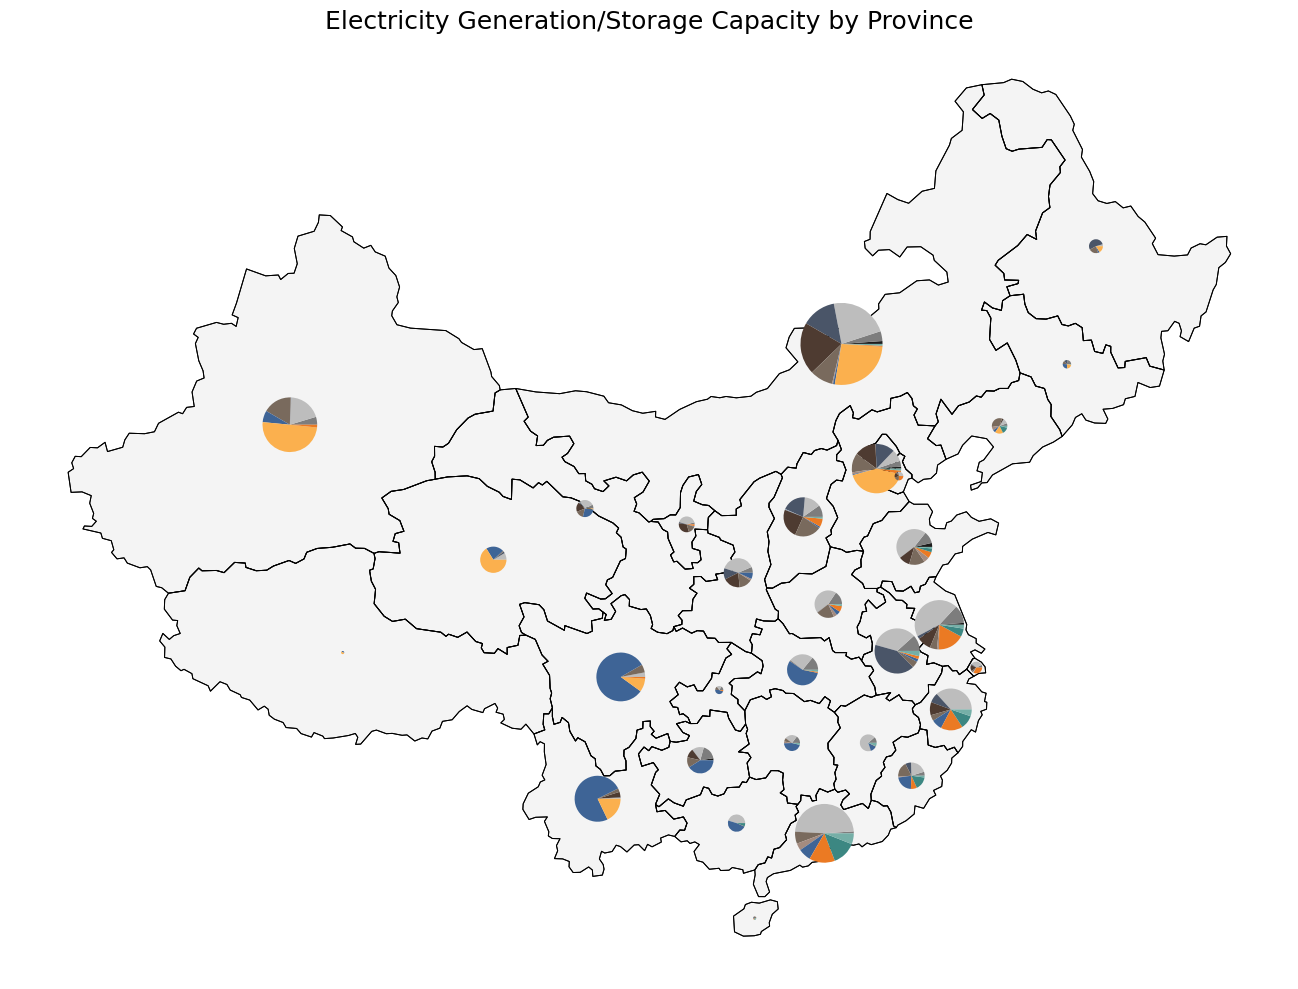

In [171]:
plot_province_pies(gdf, elec_df, colors=custom_color_map, pie_scale=3, title='Electricity Generation/Storage Capacity by Province')

In [166]:
steel_df

tech,BF-BOF,BF-BOF-CCS Retrofit,BF-BOF-CCS,Scrap EAF 56%,Scrap EAF 100% Retrofit,Scrap EAF 100%
region_name,,,,,,
Anhui,3704.804230,0.013853,0.011293,734.016954,441.444950,441.444950
Beijing,6008.216377,0.016290,0.011438,571.003756,0.207890,0.207890
Chongqing,1300.991185,0.012872,0.010754,195.000307,414.341120,414.341120
Fujian,2882.913599,0.013339,0.011606,1493.022166,452.261253,452.261253
Gansu,729.304077,0.012610,0.010203,183.000690,0.195171,0.195171
Guangdong,3304.987440,0.013804,0.011837,1545.018141,2065.587682,2065.587682
Guangxi,50.991754,0.016496,0.010867,2073.009085,0.238462,0.238462
Guizhou,399.991730,0.013339,0.010565,948.006581,219.533910,219.533910
Hebei,5309.728344,0.022705,0.011372,1629.014706,0.195184,0.195184


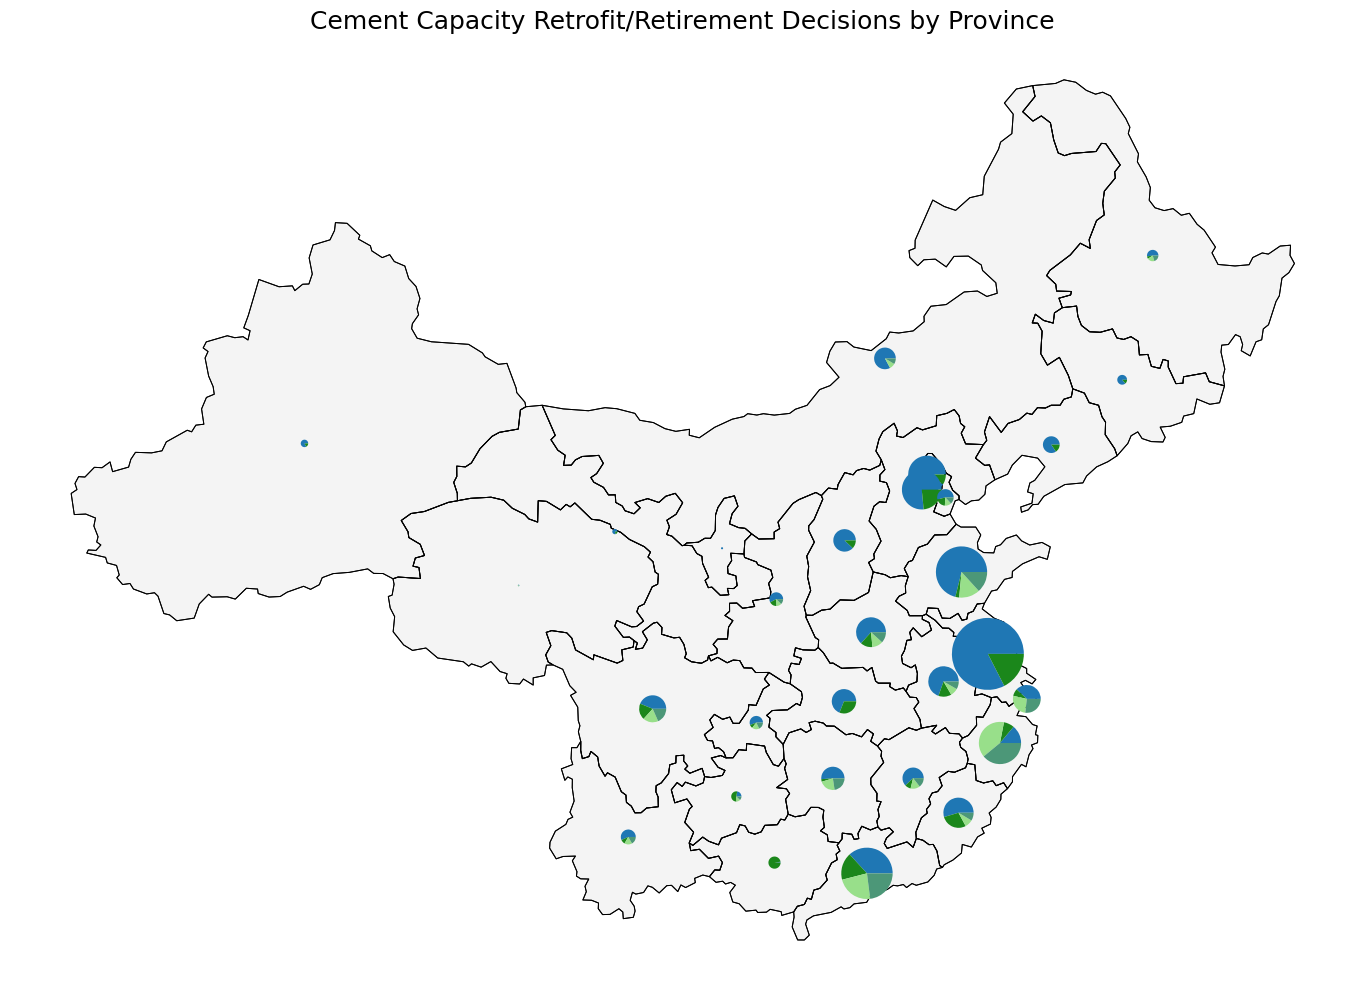

In [167]:
plot_province_pies(gdf, steel_df, colors=custom_color_map, pie_scale=2.5, title='Cement Capacity Retrofit/Retirement Decisions by Province')